In [55]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Process
1. DataFrame
2. info(),isna() for cleaning
3. define x,y
4. Train test (if needed)
5. Regression mode
6. Predicition
7. DataFrame(y/ytest, y_pred)
8. coef_,intercept
9. MAE,MSE,R2 score


In [56]:
df = pd.DataFrame({"Hours":[1,2,3,4,5,6,7],"Exam":[50,55,65,70,75,80,85]})
df

,Hours,Exam
0,1,50
1,2,55
2,3,65
3,4,70
4,5,75
5,6,80
6,7,85


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   7 non-null      int64
 1   Exam    7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [58]:
df.isna().sum()

Hours    0
Exam     0
dtype: int64

In [59]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [60]:
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x)
print(y_pred)


[50.89285714 56.78571429 62.67857143 68.57142857 74.46428571 80.35714286
 86.25      ]


In [61]:
df = pd.DataFrame({"Actual": y,"Predict":y_pred})
df["sub"] = df["Actual"]-df["Predict"]
df

,Actual,Predict,sub
0,50,50.892857,-0.892857
1,55,56.785714,-1.785714
2,65,62.678571,2.321429
3,70,68.571429,1.428571
4,75,74.464286,0.535714
5,80,80.357143,-0.357143
6,85,86.250000,-1.250000


In [62]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [5.89285714]
Intercept 45.0


In [63]:
print("MAE", metrics.mean_absolute_error(y,y_pred))
print("MSE", metrics.mean_squared_error(y,y_pred))
print("R2 Score", metrics.r2_score(y,y_pred))

MAE 1.2244897959183672
MSE 1.9132653061224514
R2 Score 0.9864130434782609


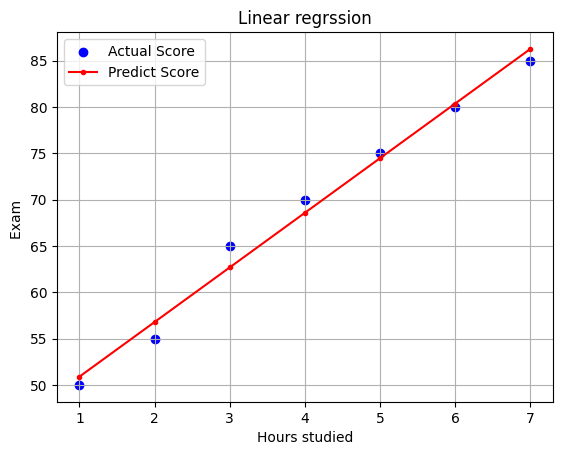

In [64]:
plt.scatter(x,y,color="blue",label = "Actual Score")
plt.plot(x,y_pred,color="red",label = "Predict Score",marker=".")
plt.xlabel("Hours studied")
plt.ylabel("Exam ")
plt.title("Linear regrssion")
plt.legend()
plt.grid()
plt.show()


In [65]:
df = pd.read_csv("Book1.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [67]:
x = df[["cgpa"]]
y = df["package"]

In [68]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=19,test_size=0.3)

In [69]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
print(y_pred)

[4.38187377 3.5439274  2.65467819 2.58057409 2.98529648 2.35826179
 3.35011667 3.18480753 2.39246368 4.12535957 3.65223339 2.79148576
 2.93399365 2.56347314 2.39816399 4.34197156 3.4698233  2.83138797
 3.23611036 2.72308197 3.09360248 2.23285485 2.64897787 3.01379806
 2.56347314 2.96249522 3.34441636 1.64002204 2.3639621  2.62617661
 1.95353939 2.15875074 3.21900942 3.23041005 3.77194002 3.73773812
 2.50646999 3.2133091  3.23041005 2.26135642 3.07080122 2.88269081
 3.84604412 3.93724916 2.97959617 3.139205   3.44132172 3.18480753
 3.49262456 3.46412298 2.98529648 2.88839112 3.19050784 2.38676336
 3.18480753 2.55207251 2.01624286 3.19620816 3.08790216 3.53822708]


In [70]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [0.57003154]
Intercept -0.9650221207944085


In [71]:
print("MAE", metrics.mean_absolute_error(y_test,y_pred))
print("MSE", metrics.mean_squared_error(y_test,y_pred))
print("R2 Score", metrics.r2_score(y_test,y_pred))

MAE 0.21067086672666643
MSE 0.07398322282163168
R2 Score 0.8104816443521474


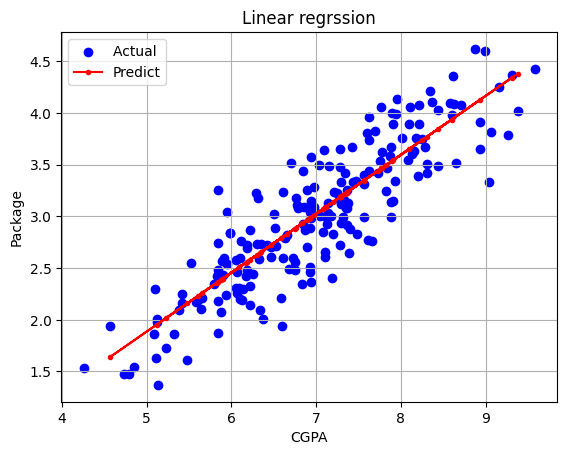

In [72]:
plt.Figure()
plt.scatter(x,y,color="blue",label = "Actual ")
plt.plot(x_test,y_pred,color="red",label = "Predict",marker=".")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("Linear regrssion")
plt.legend()
plt.grid()
plt.show()


In [73]:
m = {}
for  i in range(43):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=i)
    lr = LinearRegression()
    lr.fit(x_train,y_train)
    y_pred = lr.predict(x_test)
    m[i]= metrics.mean_absolute_error(y_test,y_pred)
minimum = min(m.values())
k = [i for i,j in m.items() if j ==minimum]
print(k,minimum)

[19] 0.21067086672666643


<Axes: xlabel='cgpa', ylabel='package'>

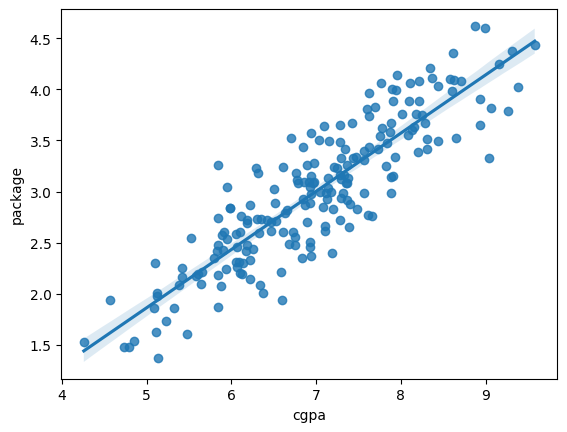

In [74]:
sns.regplot(data = df,x="cgpa",y="package")

In [81]:
# predict by giving input

x = float(input("Enter your CGPA"))
y_pred = lr.predict([[x]])
print(y_pred)

[3.89986507]


c:\Users\shubh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [98]:
# Car Data.csv

In [137]:
df = pd.read_csv("./car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [139]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [140]:
df.drop(columns=["Car_Name"], inplace=True)

In [141]:
df = pd.get_dummies(data =df,columns=["Transmission","Seller_Type","Fuel_Type"],drop_first=True)
df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Transmission_Manual,Seller_Type_Individual,Fuel_Type_Diesel,Fuel_Type_Petrol
0,2014,3.35,5.59,27000,0,True,False,False,True
1,2013,4.75,9.54,43000,0,True,False,True,False
2,2017,7.25,9.85,6900,0,True,False,False,True
3,2011,2.85,4.15,5200,0,True,False,False,True
4,2014,4.60,6.87,42450,0,True,False,True,False
...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,True,False,True,False
297,2015,4.00,5.90,60000,0,True,False,False,True
298,2009,3.35,11.00,87934,0,True,False,False,True
299,2017,11.50,12.50,9000,0,True,False,True,False


In [142]:
df["age"] = 2026 - df[["Year"]]
df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Transmission_Manual,Seller_Type_Individual,Fuel_Type_Diesel,Fuel_Type_Petrol,age
0,2014,3.35,5.59,27000,0,True,False,False,True,12
1,2013,4.75,9.54,43000,0,True,False,True,False,13
2,2017,7.25,9.85,6900,0,True,False,False,True,9
3,2011,2.85,4.15,5200,0,True,False,False,True,15
4,2014,4.60,6.87,42450,0,True,False,True,False,12
...,...,...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,0,True,False,True,False,10
297,2015,4.00,5.90,60000,0,True,False,False,True,11
298,2009,3.35,11.00,87934,0,True,False,False,True,17
299,2017,11.50,12.50,9000,0,True,False,True,False,9


In [ ]:
# we can take x = df.drop("Selling_Price",axis =1)
x = df[["age","Present_Price","Kms_Driven","Owner","Transmission_Manual","Seller_Type_Individual","Fuel_Type_Diesel","Fuel_Type_Petrol"]]
y = df["Selling_Price"]

In [160]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=32,test_size=0.3)

In [161]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [162]:
print("Coeffient", lr.coef_)
print("Intercept",lr.intercept_)

Coeffient [-4.48582746e-01  4.25248904e-01 -4.95067539e-06 -7.93010571e-01
 -1.46561481e+00 -1.18833729e+00  2.38679649e+00  3.73399960e-01]
Intercept 8.100453357021262


In [163]:
print("MAE", metrics.mean_absolute_error(y_test,y_pred))
print("MSE", metrics.mean_squared_error(y_test,y_pred))
print("R2 Score", metrics.r2_score(y_test,y_pred))

MAE 0.958824979669335
MSE 1.6487608181631686
R2 Score 0.8696877471916122


In [164]:
diff = pd.DataFrame({"Actual":y_test,"Predict":y_pred})
diff

,Actual,Predict
91,11.25,10.192560
295,8.55,9.356316
19,2.65,3.019235
276,8.65,7.734437
60,6.95,8.892513
...,...,...
190,0.20,-2.232692
255,3.00,2.737434
197,0.16,-1.303918
224,5.11,6.460413


TypeError: scatter() missing 1 required positional argument: 'y'